In [42]:
from votekit.cvr_loaders import load_scottish
from votekit.pref_profile import PreferenceProfile

pf, m, cands, parties, ward_name,  = load_scottish('/home/nardo/research/data/election_data/scot-elex/6_cands/aberdeen_2022_ward7.csv')
pf.total_ballot_wt

np.float64(4689.0)

In [3]:
100*349/600

58.166666666666664

In [13]:
import os

#iterate over every profile in scot-elex
# just count the number of profiles for now
count = 0
weights = {i: [] for i in range(6,11)}
m_values = {i: [] for i in range(6,11)}
for num_cands in range(3,15):
    for filename in os.listdir(f'/home/nardo/research/meek/data/scot-elex/{num_cands}_cands'):
        if filename.endswith('.csv'):
            count += 1
            if num_cands in [6,7,8,9,10]:
                pf, m, cands, parties, ward_name,  = load_scottish(f'/home/nardo/research/meek/data/scot-elex/{num_cands}_cands/{filename}')
                weights[num_cands].append(pf.total_ballot_wt)
                m_values[num_cands].append(m)

print(f'Total number of profiles: {count}')
print('Weights and m values for profiles with 6 to 10 candidates:')
for num_cands in range(6,11):
    print(f'Number of candidates: {num_cands}')
    print(f'average weight: {sum(weights[num_cands])/len(weights[num_cands])}')
    print(f'average m value: {sum(m_values[num_cands])/len(m_values[num_cands])}')

Total number of profiles: 1068
Weights and m values for profiles with 6 to 10 candidates:
Number of candidates: 6
average weight: 4632.8
average m value: 3.273170731707317
Number of candidates: 7
average weight: 5004.563829787234
average m value: 3.4432624113475176
Number of candidates: 8
average weight: 5384.714975845411
average m value: 3.5603864734299515
Number of candidates: 9
average weight: 5949.4152542372885
average m value: 3.694915254237288
Number of candidates: 10
average weight: 6462.492753623188
average m value: 3.8550724637681157


In [17]:
for num_cands in range(6,11):
    # count number of m values in 3, 4, 5
    m_count = {i: 0 for i in range(2,8)}
    for m in m_values[num_cands]:
        if m in m_count:
            m_count[m] += 1
    print(f'Number of candidates: {num_cands}')
    print(f'm value counts: {m_count}')

# aggregate statistics
total_weights = []
total_m_values = []
for num_cands in range(6,11):
    total_weights.extend(weights[num_cands])
    total_m_values.extend(m_values[num_cands])
print(f'Overall average weight: {sum(total_weights)/len(total_weights)}')
# overall distribution of m values
overall_m_count = {i: 0 for i in range(2,8)}
for m in total_m_values:
    if m in overall_m_count:
        overall_m_count[m] += 1
print(f'Overall m value counts: {overall_m_count}')

Number of candidates: 6
m value counts: {2: 0, 3: 146, 4: 58, 5: 0, 6: 0, 7: 0}
Number of candidates: 7
m value counts: {2: 0, 3: 157, 4: 125, 5: 0, 6: 0, 7: 0}
Number of candidates: 8
m value counts: {2: 1, 3: 90, 4: 115, 5: 1, 6: 0, 7: 0}
Number of candidates: 9
m value counts: {2: 0, 3: 36, 4: 82, 5: 0, 6: 0, 7: 0}
Number of candidates: 10
m value counts: {2: 0, 3: 10, 4: 59, 5: 0, 6: 0, 7: 0}
Overall average weight: 5248.115777525539
Overall m value counts: {2: 1, 3: 439, 4: 439, 5: 1, 6: 0, 7: 0}


In [44]:
from src.edouard.ranking_election.meek import MeekSTV, MeekCore

elec = MeekSTV(pf, m=3)
scores_array = elec._fpv_by_round[-2]
print((max(scores_array) - min(scores_array[scores_array > 0]))/pf.total_ballot_wt)

# repeat for every profile with 6,7,8,9,10 candidates
margins_per_m = {}
for num_cands in range(6,11):
    margins = []
    for filename in os.listdir(f'/home/nardo/research/meek/data/scot-elex/{num_cands}_cands'):
        if filename.endswith('.csv'):
            pf, m, cands, parties, ward_name,  = load_scottish(f'/home/nardo/research/meek/data/scot-elex/{num_cands}_cands/{filename}')
            elec = MeekSTV(pf, m=3)
            scores_array = elec._fpv_by_round[-2]
            margin = (max(scores_array) - min(scores_array[scores_array > 0]))/pf.total_ballot_wt
            margins.append(margin)
    average_margin = sum(margins)/len(margins)
    margins_per_m[num_cands] = margins
    print(f'Number of candidates: {num_cands}, Average margin: {average_margin}')

0.007191787944285951


NameError: name 'os' is not defined

In [45]:
# load the json at data/audit_results/combined.json
import json
with open('data/audit_results/combined.json', 'r') as f:
    audit_results = json.load(f)
# find a line where "status" is not "ok"
for result in audit_results:
    if result['status'] != 'ok':
        print(result)
        break

# load the corresponding "profile"
profile_path = result['path']
pf, m, cands, parties, ward_name,  = load_scottish(profile_path)
elec = MeekSTV(pf, m=3)
scores_array = elec._fpv_by_round[-2]
margin = (max(scores_array) - min(scores_array[scores_array > 0]))/pf.total_ballot_wt
print(f'Margin for the profile with audit issue: {margin}')

# repeat for every such profile in the json
margins = []
for result in audit_results:
    if result['status'] != 'ok':
        profile_path = result['path']
        pf, m, cands, parties, ward_name,  = load_scottish(profile_path)
        elec = MeekSTV(pf, m=3)
        scores_array = elec._fpv_by_round[-2]
        margin = (max(scores_array) - min(scores_array[scores_array > 0]))/pf.total_ballot_wt
        margins.append((profile_path, margin))

# find average margin
average_margin = sum(margin for _, margin in margins)/len(margins)

{'profile': 'aberdeenshire_2012_ward7.csv', 'path': 'data/scot-elex/6_cands/aberdeenshire_2012_ward7.csv', 'm': 3, 'audited_as_m': 3, 'total_ballot_wt': 3402, 'auditable_margin': 17, 'status': 'no_fraction_met_cutoff', 'sample_fraction': 1.0, 'audit_results': [{'fraction': 0.1, 'successes': 0, 'error': None}, {'fraction': 0.15, 'successes': 0, 'error': None}, {'fraction': 0.2, 'successes': 2, 'error': None}, {'fraction': 0.3333333333333333, 'successes': 6, 'error': None}, {'fraction': 0.5, 'successes': 8, 'error': None}]}
Margin for the profile with audit issue: 0.007191787944285951


In [46]:
# ratio of magins below 1%:
below_1_percent = sum(1 for _, margin in margins if margin < 0.005)
ratio_below_1_percent = below_1_percent / len(margins)
print(f'Average margin for profiles with audit issues: {average_margin}')
print(f'Ratio of margins below 1%: {ratio_below_1_percent}')

Average margin for profiles with audit issues: 0.010518631579298865
Ratio of margins below 1%: 0.6210526315789474


Fitted model: n(x) ≈ 6.47/x + -0.58


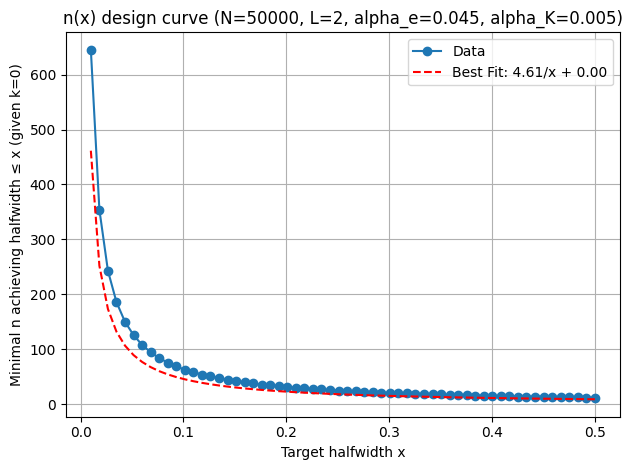

In [20]:
#!/usr/bin/env python3
"""
n(x) design curve for "eta=0" (observe k=0 successes) using hypergeometric
upper bound Ku(n) at risk alpha_K, and a normal CI halfwidth at risk alpha_e.

Assumptions:
- We sample n ballots without replacement from population size N.
- We observe X=0 "successes" (discrepancies) in the sample.
- Ku(n) is the largest K such that P(X=0 | K) >= alpha_K.
- Each ballot-level sparse variable is bounded by B=1 and has at most K nonzeros,
  giving Var(Z) <= K/N.
- If you combine L such variance bounds in your delta-method conservatism,
  we use Var(Z_total) <= L * (Ku/N).
- Finite population correction included: fpc = (N-n)/(N-1).
- Halfwidth w(n) = z_{1-alpha_e/2} * sqrt( fpc * (L*Ku/N) / n ).
"""

from __future__ import annotations

import argparse
import csv
import functools
import math
from typing import Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt


# ---------- Normal quantile (no SciPy needed): Acklam approximation ----------
def norm_ppf(p: float) -> float:
    """Inverse CDF of standard normal."""
    if p <= 0.0:
        return -math.inf
    if p >= 1.0:
        return math.inf

    # Coefficients in rational approximations (Acklam)
    a = [-3.969683028665376e+01,
          2.209460984245205e+02,
         -2.759285104469687e+02,
          1.383577518672690e+02,
         -3.066479806614716e+01,
          2.506628277459239e+00]
    b = [-5.447609879822406e+01,
          1.615858368580409e+02,
         -1.556989798598866e+02,
          6.680131188771972e+01,
         -1.328068155288572e+01]
    c = [-7.784894002430293e-03,
         -3.223964580411365e-01,
         -2.400758277161838e+00,
         -2.549732539343734e+00,
          4.374664141464968e+00,
          2.938163982698783e+00]
    d = [ 7.784695709041462e-03,
          3.224671290700398e-01,
          2.445134137142996e+00,
          3.754408661907416e+00]

    plow = 0.02425
    phigh = 1 - plow

    if p < plow:
        q = math.sqrt(-2 * math.log(p))
        return (((((c[0]*q + c[1])*q + c[2])*q + c[3])*q + c[4])*q + c[5]) / \
               ((((d[0]*q + d[1])*q + d[2])*q + d[3])*q + 1)

    if p > phigh:
        q = math.sqrt(-2 * math.log(1 - p))
        return -(((((c[0]*q + c[1])*q + c[2])*q + c[3])*q + c[4])*q + c[5]) / \
                ((((d[0]*q + d[1])*q + d[2])*q + d[3])*q + 1)

    q = p - 0.5
    r = q*q
    return (((((a[0]*r + a[1])*r + a[2])*r + a[3])*r + a[4])*r + a[5]) * q / \
           (((((b[0]*r + b[1])*r + b[2])*r + b[3])*r + b[4])*r + 1)


# ---------- Hypergeometric P(X=0 | K) in log-space ----------
def log_comb(n: int, k: int) -> float:
    if k < 0 or k > n:
        return -math.inf
    return math.lgamma(n + 1) - math.lgamma(k + 1) - math.lgamma(n - k + 1)


@functools.lru_cache(maxsize=None)
def Ku_upper_from_zero_successes(N: int, n: int, alpha_K: float) -> int:
    """
    Observed X=0. Return Ku(n) = max K such that P(X=0 | K) >= alpha_K,
    where X ~ Hypergeom(N, K, n).
    """
    if not (0 <= n <= N):
        raise ValueError("Require 0 <= n <= N.")
    if n == 0:
        # No sample => can't rule out anything
        return N

    log_denom = log_comb(N, n)
    target = math.log(alpha_K)

    # For K > N-n, we have N-K < n => P(X=0)=0
    lo, hi = 0, N - n
    while lo < hi:
        mid = (lo + hi + 1) // 2
        lp0 = log_comb(N - mid, n) - log_denom
        if lp0 >= target:
            lo = mid
        else:
            hi = mid - 1
    return lo


def halfwidth_and_Ku(
    N: int,
    n: int,
    L: int,
    alpha_e: float,
    alpha_K: float,
) -> Tuple[float, int]:
    """
    Conservative normal/Wald halfwidth using variance bound L*(Ku/N) and FPC.
    """
    Ku = Ku_upper_from_zero_successes(N, n, alpha_K)
    var_pop = (L * Ku) / N  # B=1 fixed
    fpc = (N - n) / (N - 1) if N > 1 else 0.0
    se = math.sqrt(fpc * var_pop / n) if n > 0 else math.inf
    z = norm_ppf(1 - alpha_e / 2)
    return z * se, Ku


def min_n_for_halfwidth(
    N: int,
    x: float,
    L: int,
    alpha_e: float,
    alpha_K: float,
    n_lo: int = 1,
) -> Optional[int]:
    """
    Find smallest n in [n_lo, N] s.t. halfwidth(n) <= x.
    Returns None if not achievable (shouldn't happen unless x<=0 weirdness).
    """
    if x <= 0:
        return n_lo

    # If even full census doesn't meet it (should be 0 halfwidth), fail.
    if halfwidth_and_Ku(N, N, L, alpha_e, alpha_K)[0] > x:
        return None

    lo, hi = max(1, n_lo), N
    while lo < hi:
        mid = (lo + hi) // 2
        w, _ = halfwidth_and_Ku(N, mid, L, alpha_e, alpha_K)
        if w <= x:
            hi = mid
        else:
            lo = mid + 1
    return lo


def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--N", type=int, required=True, help="Population size N")
    ap.add_argument("--L", type=int, default=1, help="Number of assorters (variance bound multiplier)")
    ap.add_argument("--alpha-e", type=float, default=0.045, help="Risk for estimation/normal CI halfwidth")
    ap.add_argument("--alpha-K", type=float, default=0.005, help="Risk for Ku upper bound (hypergeom inversion)")
    ap.add_argument("--x-min", type=float, default=1e-3, help="Minimum x (halfwidth target) for plot")
    ap.add_argument("--x-max", type=float, default=1e-1, help="Maximum x (halfwidth target) for plot")
    ap.add_argument("--num", type=int, default=60, help="Number of x points (log-spaced)")
    ap.add_argument("--no-logx", action="store_true", help="Use linear x spacing (default: log)")
    ap.add_argument("--csv", type=str, default="", help="Optional path to write CSV of (x,n,Ku,halfwidth)")
    ap.add_argument("--show-approx", action="store_true",
                    help="Also plot the large-N approximation n ≈ z*sqrt(L*-ln(alpha_K))/x")
    args = ap.parse_args()

    N = args.N
    L = args.L
    alpha_e = args.alpha_e
    alpha_K = args.alpha_K

    if N <= 1:
        raise SystemExit("Need N > 1 for meaningful sampling / FPC.")
    if not (0 < alpha_e < 1 and 0 < alpha_K < 1):
        raise SystemExit("Require 0 < alpha_e, alpha_K < 1.")
    if L <= 0:
        raise SystemExit("Require L >= 1.")
    if args.x_min <= 0 or args.x_max <= 0 or args.x_min >= args.x_max:
        raise SystemExit("Require 0 < x_min < x_max.")

    # Build x-grid
    if args.no_logx:
        xs = np.linspace(args.x_min, args.x_max, args.num)
    else:
        xs = np.logspace(math.log10(args.x_min), math.log10(args.x_max), args.num)

    # Compute n(x); exploit monotonicity: smaller x => larger n
    # We'll go from large x to small x so n_lo can increase.
    order = np.argsort(xs)[::-1]
    ns = np.zeros_like(xs, dtype=int)
    Kus = np.zeros_like(xs, dtype=int)
    ws = np.zeros_like(xs, dtype=float)

    n_lo = 1
    for idx in order:
        x = float(xs[idx])
        n = min_n_for_halfwidth(N, x, L, alpha_e, alpha_K, n_lo=n_lo)
        if n is None:
            raise SystemExit(f"Could not satisfy halfwidth <= {x} even with n=N.")
        w, Ku = halfwidth_and_Ku(N, n, L, alpha_e, alpha_K)
        ns[idx] = n
        Kus[idx] = Ku
        ws[idx] = w
        n_lo = n  # monotone

    # Optional CSV
    if args.csv:
        with open(args.csv, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["x_target", "n_min", "Ku(n)", "halfwidth(n)"])
            for x, n, Ku, w in zip(xs, ns, Kus, ws):
                writer.writerow([float(x), int(n), int(Ku), float(w)])
        print(f"Wrote CSV: {args.csv}")

    # Plot
    plt.figure()
    plt.plot(xs, ns, marker="o", linestyle="-")

    if args.show_approx:
        z = norm_ppf(1 - alpha_e / 2)
        approx = z * math.sqrt(L * (-math.log(alpha_K))) / xs
        plt.plot(xs, approx, linestyle="--")

    plt.xlabel("Target halfwidth x")
    plt.ylabel("Minimal n achieving halfwidth ≤ x (given k=0)")
    plt.title(f"n(x) design curve (N={N}, L={L}, alpha_e={alpha_e}, alpha_K={alpha_K})")
    if not args.no_logx:
        plt.xscale("log")
    plt.yscale("log")  # helpful because n ~ 1/x
    plt.grid(True, which="both")
    plt.tight_layout()
    plt.show()



N = 50000
L = 2
alpha_e = .045
alpha_K = .005

x_min = 1e-2
x_max = 5e-1
num = 60

no_logx = True

if N <= 1:
    raise SystemExit("Need N > 1 for meaningful sampling / FPC.")
if not (0 < alpha_e < 1 and 0 < alpha_K < 1):
    raise SystemExit("Require 0 < alpha_e, alpha_K < 1.")
if L <= 0:
    raise SystemExit("Require L >= 1.")
if x_min <= 0 or x_max <= 0 or x_min >= x_max:
    raise SystemExit("Require 0 < x_min < x_max.")

# Build x-grid
if no_logx:
    xs = np.linspace(x_min, x_max, num)
else:
    xs = np.logspace(math.log10(x_min), math.log10(x_max), num)

# Compute n(x); exploit monotonicity: smaller x => larger n
# We'll go from large x to small x so n_lo can increase.
order = np.argsort(xs)[::-1]
ns = np.zeros_like(xs, dtype=int)
Kus = np.zeros_like(xs, dtype=int)
ws = np.zeros_like(xs, dtype=float)

n_lo = 1
for idx in order:
    x = float(xs[idx])
    n = min_n_for_halfwidth(N, x, L, alpha_e, alpha_K, n_lo=n_lo)
    if n is None:
        raise SystemExit(f"Could not satisfy halfwidth <= {x} even with n=N.")
    w, Ku = halfwidth_and_Ku(N, n, L, alpha_e, alpha_K)
    ns[idx] = n
    Kus[idx] = Ku
    ws[idx] = w
    n_lo = n  # monotone

to_csv= False



# Optional CSV
if to_csv:
    with open("output.csv", "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["x_target", "n_min", "Ku(n)", "halfwidth(n)"])
        for x, n, Ku, w in zip(xs, ns, Kus, ws):
            writer.writerow([float(x), int(n), int(Ku), float(w)])
    print("Wrote CSV: output.csv")

# find the best fit A/x + B
from scipy.optimize import curve_fit
def model_func(x, A, B):
    return A / x + B
popt, pcov = curve_fit(model_func, xs, ns)
A_fit, B_fit = popt
print(f"Fitted model: n(x) ≈ {A_fit:.2f}/x + {B_fit:.2f}")
# also plot n(x)≈4.614L/x
A_fit, B_fit = 4.614, 0.0

# Plot
plt.figure()
plt.plot(xs, ns, marker="o", linestyle="-", label='Data')

if False:  # show_approx
    z = norm_ppf(1 - alpha_e / 2)
    approx = z * math.sqrt(L * (-math.log(alpha_K))) / xs
    plt.plot(xs, approx, linestyle="--")

# Add best fit line
plt.plot(xs, model_func(xs, A_fit, B_fit), color='red', linestyle='--', label=f'Best Fit: {A_fit:.2f}/x + {B_fit:.2f}')

plt.xlabel("Target halfwidth x")
plt.ylabel("Minimal n achieving halfwidth ≤ x (given k=0)")
plt.title(f"n(x) design curve (N={N}, L={L}, alpha_e={alpha_e}, alpha_K={alpha_K})")
if not no_logx:
    plt.xscale("log")
#plt.yscale("log")  # helpful because n ~ 1/x
plt.grid(True, which="both")
plt.legend()  # Add legend to show both data and fit line
plt.tight_layout()
plt.show()



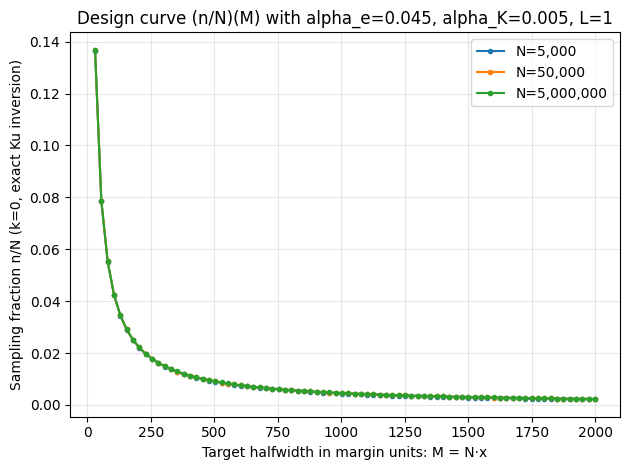

In [25]:
#!/usr/bin/env python3
"""
Plot (n/N) vs (N*x) (margin-scale halfwidth) for multiple N values,
in the k=0 (eta=0) regime using exact hypergeometric inversion for Ku(n).

Fixed risks: alpha_e=0.045, alpha_K=0.005.
Variance bound combination: Var <= L * (Ku/N), with default L=1, B=1.

X-axis: M = N*x in [10, 2000] (margin units)
Y-axis: sampling fraction n/N
Curves: N = 5,000; 50,000; 5,000,000 in different colors.
"""

from __future__ import annotations

import functools
import math
from typing import Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt


# ---------- Normal quantile (Acklam approximation; no SciPy needed) ----------
def norm_ppf(p: float) -> float:
    if p <= 0.0:
        return -math.inf
    if p >= 1.0:
        return math.inf

    a = [-3.969683028665376e+01,
          2.209460984245205e+02,
         -2.759285104469687e+02,
          1.383577518672690e+02,
         -3.066479806614716e+01,
          2.506628277459239e+00]
    b = [-5.447609879822406e+01,
          1.615858368580409e+02,
         -1.556989798598866e+02,
          6.680131188771972e+01,
         -1.328068155288572e+01]
    c = [-7.784894002430293e-03,
         -3.223964580411365e-01,
         -2.400758277161838e+00,
         -2.549732539343734e+00,
          4.374664141464968e+00,
          2.938163982698783e+00]
    d = [ 7.784695709041462e-03,
          3.224671290700398e-01,
          2.445134137142996e+00,
          3.754408661907416e+00]

    plow = 0.02425
    phigh = 1 - plow

    if p < plow:
        q = math.sqrt(-2 * math.log(p))
        return (((((c[0]*q + c[1])*q + c[2])*q + c[3])*q + c[4])*q + c[5]) / \
               ((((d[0]*q + d[1])*q + d[2])*q + d[3])*q + 1)

    if p > phigh:
        q = math.sqrt(-2 * math.log(1 - p))
        return -(((((c[0]*q + c[1])*q + c[2])*q + c[3])*q + c[4])*q + c[5]) / \
                ((((d[0]*q + d[1])*q + d[2])*q + d[3])*q + 1)

    q = p - 0.5
    r = q*q
    return (((((a[0]*r + a[1])*r + a[2])*r + a[3])*r + a[4])*r + a[5]) * q / \
           (((((b[0]*r + b[1])*r + b[2])*r + b[3])*r + b[4])*r + 1)


# ---------- Hypergeometric P(X=0 | K) in log-space ----------
def log_comb(n: int, k: int) -> float:
    if k < 0 or k > n:
        return -math.inf
    return math.lgamma(n + 1) - math.lgamma(k + 1) - math.lgamma(n - k + 1)


@functools.lru_cache(maxsize=None)
def Ku_upper_from_zero_successes(N: int, n: int, alpha_K: float) -> int:
    """
    Observed k=0 successes. Return Ku(n) = max K such that P(X=0 | K) >= alpha_K,
    where X ~ Hypergeom(N, K, n).
    """
    if not (0 <= n <= N):
        raise ValueError("Require 0 <= n <= N.")
    if n == 0:
        return N

    log_denom = log_comb(N, n)
    target = math.log(alpha_K)

    # For K > N-n, N-K < n => P(X=0)=0
    lo, hi = 0, N - n
    while lo < hi:
        mid = (lo + hi + 1) // 2
        lp0 = log_comb(N - mid, n) - log_denom
        if lp0 >= target:
            lo = mid
        else:
            hi = mid - 1
    return lo


def halfwidth_and_Ku(
    N: int,
    n: int,
    L: int,
    alpha_e: float,
    alpha_K: float,
) -> Tuple[float, int]:
    """
    Conservative normal/Wald halfwidth for the mean-scale target x, using:
      Var_pop <= L*(Ku/N)   with B=1
      Var(mean) <= fpc * Var_pop / n
      halfwidth = z * sqrt(Var(mean))
    """
    Ku = Ku_upper_from_zero_successes(N, n, alpha_K)
    var_pop = (L * Ku) / N  # B=1 fixed
    fpc = (N - n) / (N - 1) if N > 1 else 0.0
    se = math.sqrt(fpc * var_pop / n) if n > 0 else math.inf
    z = norm_ppf(1 - alpha_e / 2)
    return z * se, Ku


def min_n_for_halfwidth(
    N: int,
    x: float,
    L: int,
    alpha_e: float,
    alpha_K: float,
    n_lo: int = 1,
) -> Optional[int]:
    """Smallest n in [n_lo, N] with halfwidth(n) <= x."""
    if x <= 0:
        return n_lo

    lo, hi = max(1, n_lo), N
    while lo < hi:
        mid = (lo + hi) // 2
        w, _ = halfwidth_and_Ku(N, mid, L, alpha_e, alpha_K)
        if w <= x:
            hi = mid
        else:
            lo = mid + 1
    return lo


def compute_curve_for_N(
    N: int,
    margins: np.ndarray,
    L: int,
    alpha_e: float,
    alpha_K: float,
) -> np.ndarray:
    """
    For each margin M = N*x, compute minimal n meeting halfwidth <= x=M/N,
    then return sampling fraction n/N.
    """
    fracs = np.zeros_like(margins, dtype=float)

    # Process in descending margin to reuse monotone n_lo
    order = np.argsort(margins)[::-1]
    n_lo = 1
    for idx in order:
        M = float(margins[idx])
        x = M / N
        n = min_n_for_halfwidth(N, x, L, alpha_e, alpha_K, n_lo=n_lo)
        if n is None:
            raise RuntimeError(f"Not achievable for N={N}, margin={M}")
        fracs[idx] = n / N
        n_lo = n
    return fracs


#def main() -> None:
#    # ---- User-tunable parameters ----
alpha_e = 0.045
alpha_K = 0.005
L = 1

Ns = [5_000, 50_000, 5_000_000]

margin_min = 30
margin_max = 2000
num_points = 80  # increase for smoother curves

# Linear grid in margin units (N*x)
margins = np.linspace(margin_min, margin_max, num_points)

# ---- Compute and plot ----
plt.figure()

colors = ["tab:blue", "tab:orange", "tab:green"]
for N, c in zip(Ns, colors):
    fracs = compute_curve_for_N(N, margins, L, alpha_e, alpha_K)
    plt.plot(margins, fracs, color=c, marker="o", markersize=3, linewidth=1.5, label=f"N={N:,}")

plt.xlabel("Target halfwidth in margin units: M = N·x")
plt.ylabel("Sampling fraction n/N (k=0, exact Ku inversion)")
plt.title(f"Design curve (n/N)(M) with alpha_e={alpha_e}, alpha_K={alpha_K}, L={L}")
plt.grid(True, which="both", alpha=0.3)

# Fraction can still span decades across N; log-y helps comparisons.
#plt.yscale("log")

plt.legend()
plt.tight_layout()
plt.show()



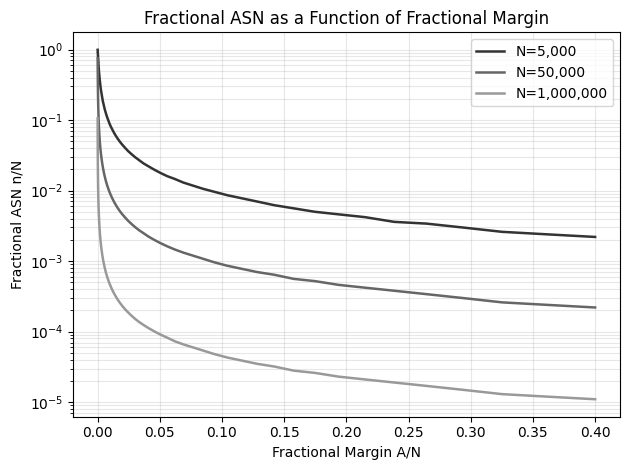

In [35]:
#!/usr/bin/env python3
"""
Plot sampling fraction n/N (y-axis) vs mean-scale halfwidth target x (x-axis),
for multiple N values, in the k=0 (eta=0) regime using exact hypergeometric
inversion for Ku(n).

Fixed risks: alpha_e=0.045, alpha_K=0.005.
Variance bound combo: Var_pop <= L*(Ku/N), with default L=1, B=1.

Curves: N = 5,000; 50,000; 5,000,000 in different colors.
"""

from __future__ import annotations

import functools
import math
from typing import Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt


# ---------- Normal quantile (Acklam approximation; no SciPy needed) ----------
def norm_ppf(p: float) -> float:
    if p <= 0.0:
        return -math.inf
    if p >= 1.0:
        return math.inf

    a = [-3.969683028665376e+01,
          2.209460984245205e+02,
         -2.759285104469687e+02,
          1.383577518672690e+02,
         -3.066479806614716e+01,
          2.506628277459239e+00]
    b = [-5.447609879822406e+01,
          1.615858368580409e+02,
         -1.556989798598866e+02,
          6.680131188771972e+01,
         -1.328068155288572e+01]
    c = [-7.784894002430293e-03,
         -3.223964580411365e-01,
         -2.400758277161838e+00,
         -2.549732539343734e+00,
          4.374664141464968e+00,
          2.938163982698783e+00]
    d = [ 7.784695709041462e-03,
          3.224671290700398e-01,
          2.445134137142996e+00,
          3.754408661907416e+00]

    plow = 0.02425
    phigh = 1 - plow

    if p < plow:
        q = math.sqrt(-2 * math.log(p))
        return (((((c[0]*q + c[1])*q + c[2])*q + c[3])*q + c[4])*q + c[5]) / \
               ((((d[0]*q + d[1])*q + d[2])*q + d[3])*q + 1)

    if p > phigh:
        q = math.sqrt(-2 * math.log(1 - p))
        return -(((((c[0]*q + c[1])*q + c[2])*q + c[3])*q + c[4])*q + c[5]) / \
                ((((d[0]*q + d[1])*q + d[2])*q + d[3])*q + 1)

    q = p - 0.5
    r = q*q
    return (((((a[0]*r + a[1])*r + a[2])*r + a[3])*r + a[4])*r + a[5]) * q / \
           (((((b[0]*r + b[1])*r + b[2])*r + b[3])*r + b[4])*r + 1)


# ---------- Hypergeometric P(X=0 | K) in log-space ----------
def log_comb(n: int, k: int) -> float:
    if k < 0 or k > n:
        return -math.inf
    return math.lgamma(n + 1) - math.lgamma(k + 1) - math.lgamma(n - k + 1)


@functools.lru_cache(maxsize=None)
def Ku_upper_from_zero_successes(N: int, n: int, alpha_K: float) -> int:
    """
    Observed k=0 successes. Return Ku(n) = max K such that P(X=0 | K) >= alpha_K,
    where X ~ Hypergeom(N, K, n).
    """
    if not (0 <= n <= N):
        raise ValueError("Require 0 <= n <= N.")
    if n == 0:
        return N

    log_denom = log_comb(N, n)
    target = math.log(alpha_K)

    # For K > N-n, N-K < n => P(X=0)=0
    lo, hi = 0, N - n
    while lo < hi:
        mid = (lo + hi + 1) // 2
        lp0 = log_comb(N - mid, n) - log_denom
        if lp0 >= target:
            lo = mid
        else:
            hi = mid - 1
    return lo


def halfwidth(
    N: int,
    n: int,
    L: int,
    alpha_e: float,
    alpha_K: float,
) -> float:
    """
    Conservative normal/Wald halfwidth for the mean-scale target x, using:
      Var_pop <= L*(Ku/N)   (B=1)
      Var(mean) <= fpc * Var_pop / n
      halfwidth = z * sqrt(Var(mean))
    """
    Ku = Ku_upper_from_zero_successes(N, n, alpha_K)
    var_pop = (L * Ku) / N
    fpc = (N - n) / (N - 1) if N > 1 else 0.0
    se = math.sqrt(fpc * var_pop / n) if n > 0 else math.inf
    z = norm_ppf(1 - alpha_e / 2)
    return z * se


def min_n_for_halfwidth(
    N: int,
    x: float,
    L: int,
    alpha_e: float,
    alpha_K: float,
    n_lo: int = 1,
    n_hi: Optional[int] = None,
) -> int:
    """Smallest n in [n_lo, n_hi] with halfwidth(n) <= x."""
    if x <= 0:
        return max(1, n_lo)

    lo = max(1, n_lo)
    hi = N if n_hi is None else min(N, max(lo, n_hi))

    # Ensure hi is feasible; expand to N if needed
    if halfwidth(N, hi, L, alpha_e, alpha_K) > x:
        hi = N

    # Binary search
    while lo < hi:
        mid = (lo + hi) // 2
        if halfwidth(N, mid, L, alpha_e, alpha_K) <= x:
            hi = mid
        else:
            lo = mid + 1
    return lo


#def main() -> None:
# --- fixed per your setup ---
alpha_e = 0.045
alpha_K = 0.005
L = 1

Ns = [5_000, 50_000, 1_000_000]
colors = ["tab:blue", "tab:orange", "tab:green"]

# Choose an x-range that spans the *same margin range* 10..2000 across all N:
# x = M/N, so overall x range is [10/maxN, 2000/minN].
x_min = 40 / max(Ns)          # 2e-6 for 5,000,000
x_max = 2000 / min(Ns)        # 0.4  for 5,000
num_points = 90
xs = np.logspace(math.log10(x_min), math.log10(x_max), num_points)

# Helpful asymptotic constant for an initial bracket: n ≈ C*sqrt(L)/x
z = norm_ppf(1 - alpha_e / 2)
C = z * math.sqrt(-math.log(alpha_K)) * math.sqrt(L)

plt.figure()
# Use grayscale colors instead of the previous colors
grays = [f'0.{i}' for i in range(2, 9, 2)]  # Creates grayscale values from light to dark
for N, c in zip(Ns, grays):
    fracs = np.zeros_like(xs, dtype=float)

    # Rest of the code remains the same...
    order = np.argsort(xs)[::-1]
    n_lo = 1
    for idx in order:
        x = float(xs[idx])

        n_guess = int(math.ceil(C / x))
        n_hi = min(N, max(n_lo, 2 * n_guess))

        n = min_n_for_halfwidth(N, x, L, alpha_e, alpha_K, n_lo=n_lo, n_hi=n_hi)
        fracs[idx] = n / N
        n_lo = n

    plt.plot(xs, fracs, color=c, linewidth=1.8, label=f"N={N:,}")

plt.yscale("log")
#plt.xscale("log")
plt.xlabel("Fractional Margin A/N")
plt.ylabel("Fractional ASN n/N")
plt.title(f"Fractional ASN as a Function of Fractional Margin")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


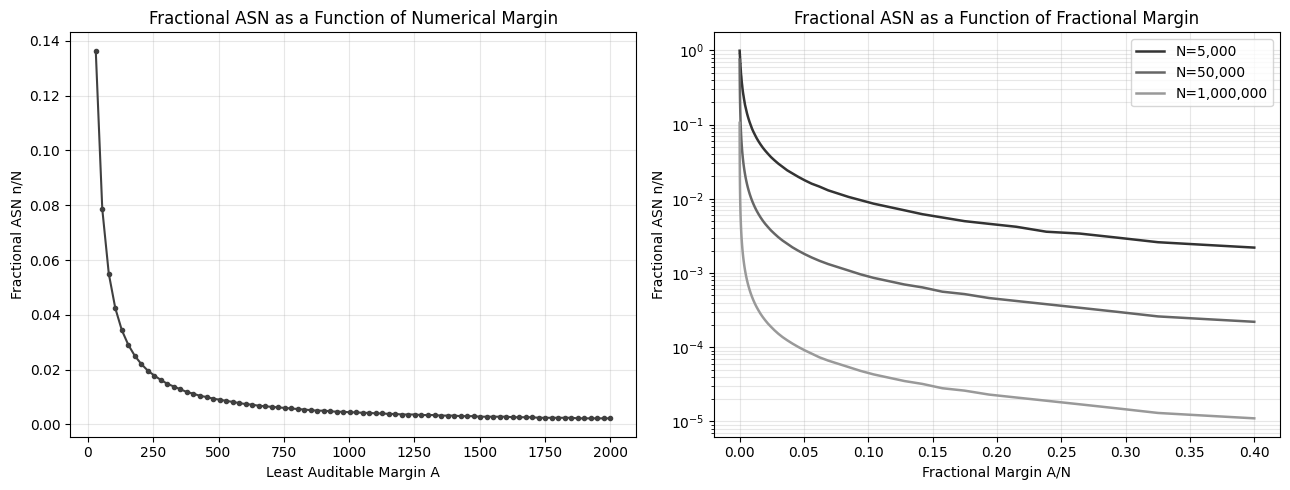

In [48]:
#!/usr/bin/env python3
from __future__ import annotations

import functools
import math
from typing import Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt


# ---------- Normal quantile (Acklam approximation; no SciPy needed) ----------
def norm_ppf(p: float) -> float:
    if p <= 0.0:
        return -math.inf
    if p >= 1.0:
        return math.inf

    a = [-3.969683028665376e+01,
          2.209460984245205e+02,
         -2.759285104469687e+02,
          1.383577518672690e+02,
         -3.066479806614716e+01,
          2.506628277459239e+00]
    b = [-5.447609879822406e+01,
          1.615858368580409e+02,
         -1.556989798598866e+02,
          6.680131188771972e+01,
         -1.328068155288572e+01]
    c = [-7.784894002430293e-03,
         -3.223964580411365e-01,
         -2.400758277161838e+00,
         -2.549732539343734e+00,
          4.374664141464968e+00,
          2.938163982698783e+00]
    d = [ 7.784695709041462e-03,
          3.224671290700398e-01,
          2.445134137142996e+00,
          3.754408661907416e+00]

    plow = 0.02425
    phigh = 1 - plow

    if p < plow:
        q = math.sqrt(-2 * math.log(p))
        return (((((c[0]*q + c[1])*q + c[2])*q + c[3])*q + c[4])*q + c[5]) / \
               ((((d[0]*q + d[1])*q + d[2])*q + d[3])*q + 1)

    if p > phigh:
        q = math.sqrt(-2 * math.log(1 - p))
        return -(((((c[0]*q + c[1])*q + c[2])*q + c[3])*q + c[4])*q + c[5]) / \
                ((((d[0]*q + d[1])*q + d[2])*q + d[3])*q + 1)

    q = p - 0.5
    r = q*q
    return (((((a[0]*r + a[1])*r + a[2])*r + a[3])*r + a[4])*r + a[5]) * q / \
           (((((b[0]*r + b[1])*r + b[2])*r + b[3])*r + b[4])*r + 1)


# ---------- Hypergeometric P(X=0 | K) in log-space ----------
def log_comb(n: int, k: int) -> float:
    if k < 0 or k > n:
        return -math.inf
    return math.lgamma(n + 1) - math.lgamma(k + 1) - math.lgamma(n - k + 1)


@functools.lru_cache(maxsize=None)
def Ku_upper_from_zero_successes(N: int, n: int, alpha_K: float) -> int:
    """
    Observed k=0 successes. Return Ku(n) = max K such that P(X=0 | K) >= alpha_K,
    where X ~ Hypergeom(N, K, n).
    """
    if not (0 <= n <= N):
        raise ValueError("Require 0 <= n <= N.")
    if n == 0:
        return N

    log_denom = log_comb(N, n)
    target = math.log(alpha_K)

    lo, hi = 0, N - n
    while lo < hi:
        mid = (lo + hi + 1) // 2
        lp0 = log_comb(N - mid, n) - log_denom
        if lp0 >= target:
            lo = mid
        else:
            hi = mid - 1
    return lo


# ===== Left-panel helpers (margin-scale M = N*x) =====
def halfwidth_and_Ku(
    N: int,
    n: int,
    L: int,
    alpha_e: float,
    alpha_K: float,
) -> Tuple[float, int]:
    Ku = Ku_upper_from_zero_successes(N, n, alpha_K)
    var_pop = (L * Ku) / N
    fpc = (N - n) / (N - 1) if N > 1 else 0.0
    se = math.sqrt(fpc * var_pop / n) if n > 0 else math.inf
    z = norm_ppf(1 - alpha_e / 2)
    return z * se, Ku


def min_n_for_halfwidth_M(
    N: int,
    x: float,
    L: int,
    alpha_e: float,
    alpha_K: float,
    n_lo: int = 1,
) -> int:
    if x <= 0:
        return max(1, n_lo)

    lo, hi = max(1, n_lo), N
    while lo < hi:
        mid = (lo + hi) // 2
        w, _ = halfwidth_and_Ku(N, mid, L, alpha_e, alpha_K)
        if w <= x:
            hi = mid
        else:
            lo = mid + 1
    return lo


def compute_curve_for_N_M(
    N: int,
    margins: np.ndarray,
    L: int,
    alpha_e: float,
    alpha_K: float,
) -> np.ndarray:
    fracs = np.zeros_like(margins, dtype=float)
    order = np.argsort(margins)[::-1]
    n_lo = 1
    for idx in order:
        M = float(margins[idx])
        x = M / N
        n = min_n_for_halfwidth_M(N, x, L, alpha_e, alpha_K, n_lo=n_lo)
        fracs[idx] = n / N
        n_lo = n
    return fracs


# ===== Right-panel helpers (fractional x on x-axis) =====
def halfwidth_x(
    N: int,
    n: int,
    L: int,
    alpha_e: float,
    alpha_K: float,
) -> float:
    Ku = Ku_upper_from_zero_successes(N, n, alpha_K)
    var_pop = (L * Ku) / N
    fpc = (N - n) / (N - 1) if N > 1 else 0.0
    se = math.sqrt(fpc * var_pop / n) if n > 0 else math.inf
    z = norm_ppf(1 - alpha_e / 2)
    return z * se


def min_n_for_halfwidth_x(
    N: int,
    x: float,
    L: int,
    alpha_e: float,
    alpha_K: float,
    n_lo: int = 1,
    n_hi: Optional[int] = None,
) -> int:
    if x <= 0:
        return max(1, n_lo)

    lo = max(1, n_lo)
    hi = N if n_hi is None else min(N, max(lo, n_hi))

    if halfwidth_x(N, hi, L, alpha_e, alpha_K) > x:
        hi = N

    while lo < hi:
        mid = (lo + hi) // 2
        if halfwidth_x(N, mid, L, alpha_e, alpha_K) <= x:
            hi = mid
        else:
            lo = mid + 1
    return lo


# ===================== Plot side-by-side =====================
alpha_e = 0.045
alpha_K = 0.005
L = 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ---- LEFT (adapted first figure): only N=5000, grayscale, no legend ----
N_left = 5_000
margin_min = 30
margin_max = 2000
num_points = 80
margins = np.linspace(margin_min, margin_max, num_points)

fracs_left = compute_curve_for_N_M(N_left, margins, L, alpha_e, alpha_K)
ax1.plot(margins, fracs_left, color="0.25", marker="o", markersize=3, linewidth=1.5)

ax1.set_xlabel("Least Auditable Margin A")
ax1.set_ylabel("Fractional ASN n/N")
ax1.set_title(f"Fractional ASN as a Function of Numerical Margin")
ax1.grid(True, which="both", alpha=0.3)
# (no legend)

# ---- RIGHT (your second figure, same settings/appearance; just drawn on ax2) ----
Ns = [5_000, 50_000, 1_000_000]
# Helpful asymptotic constant for an initial bracket: n ≈ C*sqrt(L)/x
z = norm_ppf(1 - alpha_e)
C = z * math.sqrt(-math.log(alpha_K)) * math.sqrt(L)

# Choose an x-range that spans the *same margin range* 10..2000 across all N:
x_min = 40 / max(Ns)
x_max = 2000 / min(Ns)
num_points = 90
xs = np.logspace(math.log10(x_min), math.log10(x_max), num_points)

# Use grayscale colors instead of the previous colors
grays = [f'0.{i}' for i in range(2, 9, 2)]
for N, c in zip(Ns, grays):
    fracs = np.zeros_like(xs, dtype=float)

    order = np.argsort(xs)[::-1]
    n_lo = 1
    for idx in order:
        x = float(xs[idx])

        n_guess = int(math.ceil(C / x))
        n_hi = min(N, max(n_lo, 2 * n_guess))

        n = min_n_for_halfwidth_x(N, x, L, alpha_e, alpha_K, n_lo=n_lo, n_hi=n_hi)
        fracs[idx] = n / N
        n_lo = n

    ax2.plot(xs, fracs, color=c, linewidth=1.8, label=f"N={N:,}")

ax2.set_yscale("log")
# ax2.set_xscale("log")
ax2.set_xlabel("Fractional Margin A/N")
ax2.set_ylabel("Fractional ASN n/N")
ax2.set_title("Fractional ASN as a Function of Fractional Margin")
ax2.grid(True, which="both", alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()
